In [1]:
from IPython.display import Image
import xarray as xr
#import xclim as xc
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import to_hex
import matplotlib.ticker as mticker

In [4]:
import xarray as xr
import numpy as np
import threading

# ── PAS de LocalCluster — scheduler synchrone pour la lecture ────────────────
# On n'utilise Dask distribué QUE si nécessaire pour les calculs lourds

# Lock global HDF5 : force l'accès séquentiel aux fichiers
HDF5_LOCK = threading.Lock()

# ── Helper preprocess ────────────────────────────────────────────────────────
def preprocess_pr(ds):
    ds = ds.sel(latitude=slice(-10, -44), longitude=slice(112, 154))
    if 'expver' in ds.dims:
        ds = ds.sel(expver=1, drop=True).combine_first(ds.sel(expver=5, drop=True))
    return ds[['tp']]

def preprocess_mslp(ds):
    return ds[['msl']].sel(latitude=[-40, -65], method='nearest')

# ── 1. PR (ERA5) ──────────────────────────────────────────────────────────────
import glob, os
files_pr = sorted(glob.glob('/g/data/rt52/era5/single-levels/monthly-averaged/tp/**/*.nc',
                             recursive=True))
print(f"{len(files_pr)} fichiers PR trouvés")

ds_pr = xr.open_mfdataset(
    files_pr,
    parallel=False,
    preprocess=preprocess_pr,
    combine='by_coords',
    engine='netcdf4',
    chunks={'time': 12},
    # Pas de Dask distribué : scheduler='synchronous' forcé au compute
)
prec = ds_pr.tp * 1000
print("PR ouvert ✓")


804 fichiers PR trouvés
PR ouvert ✓


In [5]:
prec_mean = prec.mean(dim="time")
prec_mean_yr = prec_mean*365
#creating a colorbar
my_levels = [0,100,200,300,400,500,600,700,800,900,1000,1100,1200]

#creating a colorbar
lev = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]
#lev = [0,10,20,30,40,50,60,70,80,90,100]

#carte qui montre le % de precipitation annuel dans les mois de NDJFM
# creer une carte avec juste la moyenne de prec depuis 1940 pour les mois nov a avril l'annee suivante
prec_NDJFMA = prec.sel(
    time=(prec['time.month'] >= 12) | (prec['time.month'] <= 2))

# Pour faire la moyenne 
meanPrec_NDJFMA = prec_NDJFMA.mean(dim='time')*3
PercentageNDJFM = meanPrec_NDJFMA / (prec_mean*12)*100

# juste voir le changement de presison pendant la saison de la mousson en general \
precNDJFMAanomaly = (meanPrec_NDJFMA - prec_mean)

/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


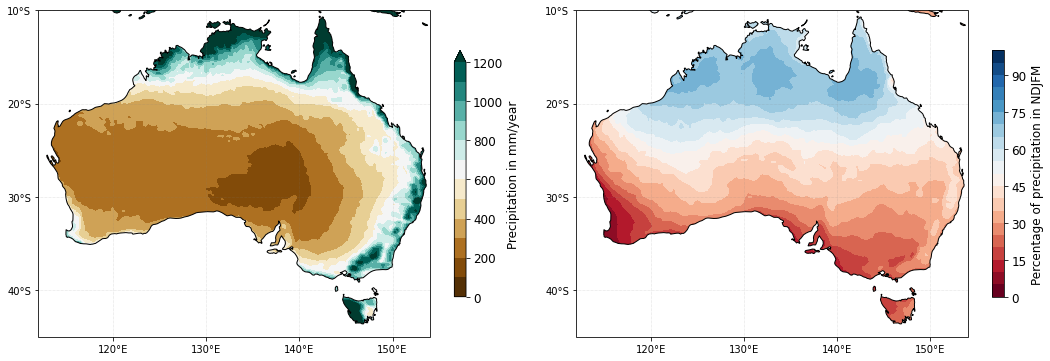

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Créer une figure avec 2 sous-graphes côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Première carte
ax1.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linestyle='-')
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')

# Ajouter les labels de latitude et longitude pour la première carte
ax1.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax1.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=10)
ax1.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax1.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=10)
ax1.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)

# Première carte
contour1 = prec_mean_yr.plot.contourf(
    ax=ax1, 
    transform=ccrs.PlateCarree(), 
    levels=my_levels, 
    cmap='BrBG', 
    add_colorbar=True, 
    cbar_kwargs={
        'label': 'Precipitation in mm/year',  # Titre de la colorbar
        'shrink': 0.6
    },
    zorder=0
)
# Supprimer les labels automatiques
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('')
# Ajuster la taille de l'étiquette et des ticks pour la première carte
contour1.colorbar.set_label('Precipitation in mm/year', size=12)  # Taille de l'étiquette
contour1.colorbar.ax.tick_params(labelsize=12)  # Taille des ticks (my_levels)

# Première carte
ax2.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, linestyle='-')
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')

# Ajouter les labels de latitude et longitude pour la première carte
ax2.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax2.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=10)
ax2.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax2.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=10)
ax2.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)

# Deuxième carte
contour2 = PercentageNDJFM.plot.contourf(
    ax=ax2, 
    transform=ccrs.PlateCarree(), 
    levels=lev, 
    cmap='RdBu', 
    add_colorbar=True, 
    cbar_kwargs={
        'label': 'Percentage of precipitation',  # Titre de la colorbar
        'shrink': 0.6
    },
    zorder=0
)

# Ajuster la taille de l'étiquette et des ticks pour la deuxième carte
contour2.colorbar.set_label('Percentage of precipitation in NDJFM', size=12)  # Taille de l'étiquette
contour2.colorbar.ax.tick_params(labelsize=12)  # Taille des ticks (lev)


# Supprimer les labels automatiques
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('')

# Afficher les cartes
plt.tight_layout()
plt.show()

/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1781: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)


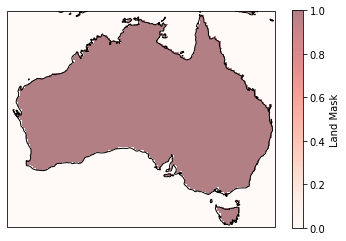

In [8]:
#Faire la moyenne mensuelle de précipitation sur toute la régio AUM
# Mask region in land + Nord de 23 degres
import cartopy.feature as cfeature
from shapely.geometry import Polygon
from matplotlib.path import Path

# Définir la région d'intérêt
lon_min, lon_max, lat_min, lat_max = 112, 154, -44, -10

lons, lats = np.meshgrid(np.linspace(lon_min, lon_max, 168),
                         np.linspace(lat_min, lat_max, 136))
# Créer une carte pour obtenir les caractéristiques de la côte
#fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
#ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Récupérer les caractéristiques de la côte
coastline = cfeature.COASTLINE
coastline_geom = coastline.geometries()

# Créer une géométrie de type Polygon pour la région d'intérêt
bbox_polygon = Polygon([(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)])

# Initialiser le masque de terre
land_mask = np.zeros((136, 168), dtype=bool)

# Remplir le masque avec les zones terrestres
for geom in coastline_geom:
    if bbox_polygon.intersects(geom):
        # Convertir les coordonnées de la géométrie de la côte
        coords = np.array(geom.xy).T
        # Créer un chemin à partir des coordonnées
        path = Path(coords)
        # Vérifier si chaque point dans la grille est à l'intérieur du chemin
        land_mask |= path.contains_points(np.column_stack((lons.flatten(), lats.flatten()))).reshape(136, 168)

# Inverser l'axe y du masque de terre
#land_mask = np.flipud(land_mask)

# Redéfinir les grilles de longitude/lattitude avec la nouvelle taille
lons, lats = np.meshgrid(np.linspace(lon_min, lon_max, land_mask.shape[1]),
                         np.linspace(lat_min, lat_max, land_mask.shape[0]))

# Visualiser le masque
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
pcm = ax.pcolormesh(lons, lats, land_mask, cmap='Reds', transform=ccrs.PlateCarree(), alpha=0.5)
plt.colorbar(pcm, label='Land Mask')

ax.add_feature(cfeature.COASTLINE, linestyle='-')
plt.show()

In [9]:
# Autre mask ressemblant pour l'appliquer aux models
prec_AUS = prec.sel(longitude=np.arange(112, 154, 0.25), latitude=np.arange(-44, -10, 0.25)).load()
NA = (prec_AUS['latitude'] >= -23) & (prec_AUS['latitude'] <= -11) & (prec_AUS['longitude'] >= 122) & (prec_AUS['longitude'] <= 149)

# Afficher le masque
#NA = prec.sel(lat=slice(-11,-23), lon=slice(-149, -122))

mask3 = land_mask & NA
prec_mean_AUM = prec.where(mask3)

# Faire la moyenne des prec dans l'AUM
monthly_mean = prec_mean_AUM.groupby('time.month').mean(dim='time')
prec_mean_AUM1 = monthly_mean.mean(dim="latitude")
prec_mean_AUM2 = prec_mean_AUM1.mean(dim="longitude")

data = [prec_mean_AUM2[0]*31, prec_mean_AUM2[1]*28.25,prec_mean_AUM2[2]*31,prec_mean_AUM2[3]*30,prec_mean_AUM2[4]*31,
        prec_mean_AUM2[5]*30,prec_mean_AUM2[6]*31, prec_mean_AUM2[7]*31,prec_mean_AUM2[8]*30, prec_mean_AUM2[9]*31,
        prec_mean_AUM2[10]*30, prec_mean_AUM2[11]*31]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_prec_mm = xr.DataArray(data, dims='month', coords={'month': range(1, 13)})

# Changer les valeurs de l'index 'month' en 'Jan', 'Feb', 'Mar', ...
monthly_prec_mm = monthly_prec_mm.assign_coords(month=months)

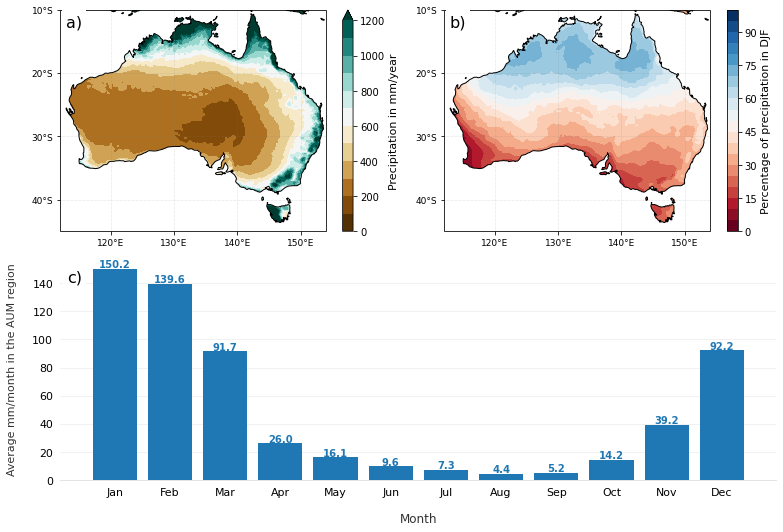

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Créer une grille de 3 sous-graphes (2 pour les cartes et 1 pour le barplot)
fig = plt.figure(figsize=(11, 7.5))  # Ajuster la taille de la figure
gs = fig.add_gridspec(2, 2, height_ratios=[2, 2])  # 2 rangées, 2 colonnes, 1ère rangée pour les cartes, 2ème pour le barplot

# Première carte
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax1.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linestyle='-')
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')
# Ajouter les labels de latitude et longitude pour la première carte
ax1.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax1.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=9)
ax1.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax1.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=9)
ax1.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)
contour1 = prec_mean_yr.plot.contourf(ax=ax1, transform=ccrs.PlateCarree(), levels=my_levels, cmap='BrBG', add_colorbar=True, cbar_kwargs={'label': 'Precipitation in mm/year', 'shrink': 1}, zorder=0)

# Supprimer les labels automatiques
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('')

contour1.colorbar.set_label('Precipitation in mm/year', size=11)  # Taille de l'étiquette
contour1.colorbar.ax.tick_params(labelsize=10)  # Taille des ticks (my_levels)
ax1.text(0.02, 0.98, 'a)', transform=ax1.transAxes, ha='left', va='top', fontsize=16, bbox=dict(facecolor='white', edgecolor='none'))

# Deuxième carte
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, linestyle='-')
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')
# Ajouter les labels de latitude et longitude pour la première carte
ax2.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax2.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=9)
ax2.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax2.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=9)
ax2.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)
contour2 = PercentageNDJFM.plot.contourf(ax=ax2, transform=ccrs.PlateCarree(), levels=lev, cmap='RdBu', add_colorbar=True, cbar_kwargs={'label': 'Percentage of precipitation in NDJFM', 'shrink': 1}, zorder=0)

# Supprimer les labels automatiques
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('')

contour2.colorbar.set_label('Percentage of precipitation in DJF', size=11)  # Taille de l'étiquette
contour2.colorbar.ax.tick_params(labelsize=10)  # Taille des ticks (my_levels)
ax2.text(0.02, 0.98, 'b)', transform=ax2.transAxes, ha='left', va='top', fontsize=16, bbox=dict(facecolor='white', edgecolor='none'))

# Barplot
ax3 = fig.add_subplot(gs[1, 0:])  # Le barplot occupe toute la deuxième rangée (fusion des deux colonnes)
bars = ax3.bar(
    x=range(len(months)),
    height=monthly_prec_mm,
    tick_label=months
)

# Axis formatting for barplot
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['bottom'].set_color('#DDDDDD')
ax3.tick_params(bottom=False, left=False, labelsize=11)
ax3.set_axisbelow(True)
ax3.yaxis.grid(True, color='#EEEEEE')
ax3.xaxis.grid(False)
ax3.text(0.01, 0.95, 'c)', transform=ax3.transAxes, ha='left', va='top', fontsize=16, bbox=dict(facecolor='white', edgecolor='none'))

# Add text annotations to the top of the bars
bar_color = bars[0].get_facecolor()
for bar in bars:
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        round(bar.get_height(), 1),
        horizontalalignment='center',
        color=bar_color,
        weight='bold'
    )

# Add labels and title to the barplot
ax3.set_xlabel('Month', labelpad=15, color='#333333', fontsize='12')
ax3.set_ylabel('Average mm/month in the AUM region', labelpad=15, color='#333333', fontsize='11')
ax3.set_title('')

# Ajuster l'espacement entre les sous-graphes
fig.tight_layout()

fig.savefig('Map+barplot_Intro.png', bbox_inches='tight', dpi=600)
plt.show()

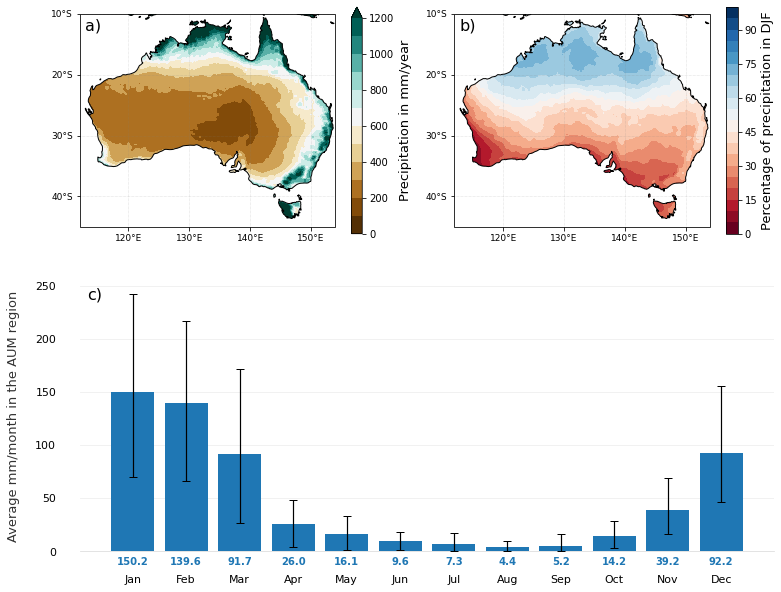

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- 1. Préparation des données ---
# (On suppose que les variables prec_mean_yr, PercentageNDJFM, monthly_prec_mm, 
# months, prec, mask3, my_levels et lev sont déjà définies dans votre espace de travail)

spatial_mean_series = prec.where(mask3).mean(dim=['latitude', 'longitude'])
percentile_low = []
percentile_high = []
days_in_months = [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

for i, m in enumerate(range(1, 13)):
    month_data = spatial_mean_series.sel(time=spatial_mean_series['time.month'] == m)
    data_mm = month_data.values * days_in_months[i]
    
    p10 = np.nanpercentile(data_mm, 10)
    p90 = np.nanpercentile(data_mm, 90)
    
    percentile_low.append(p10)
    percentile_high.append(p90)

lower_err = np.maximum(0, monthly_prec_mm.values - np.array(percentile_low))
upper_err = np.maximum(0, np.array(percentile_high) - monthly_prec_mm.values)
yerr = [lower_err, upper_err]

# --- 2. Création de la figure ---
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1]) 

# --- Carte A ---
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax1.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linestyle='-', linewidth=1)
ax1.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
ax1.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')

ax1.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax1.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=9)
ax1.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax1.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=9)
ax1.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)

contour1 = prec_mean_yr.plot.contourf(
    ax=ax1, 
    transform=ccrs.PlateCarree(), 
    levels=my_levels, 
    cmap='BrBG', 
    add_colorbar=True, 
    cbar_kwargs={'shrink': 0.7}, 
    zorder=0
)

# On modifie le label manuellement via l'objet colorbar
contour1.colorbar.set_label('Precipitation in mm/year', size=13)

# Si vous voulez aussi changer la taille des chiffres (ticks) de la colorbar :
contour1.colorbar.ax.tick_params(labelsize=10)

# Suppression des labels d'axes indésirables
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('')
ax1.text(0.02, 0.98, 'a)', transform=ax1.transAxes, ha='left', va='top', fontsize=16)

# --- Carte B ---
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2.set_extent([112, 154, -10, -45], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, linestyle='-', linewidth=1)
ax2.add_feature(cfeature.OCEAN, zorder=1, facecolor='white')

ax2.set_xticks([120, 130, 140, 150], crs=ccrs.PlateCarree())
ax2.set_xticklabels(['120°E', '130°E', '140°E', '150°E'], fontsize=9)
ax2.set_yticks([-40, -30, -20, -10], crs=ccrs.PlateCarree())
ax2.set_yticklabels(['40°S', '30°S', '20°S', '10°S'], fontsize=9)
ax2.grid(linewidth=0.5, linestyle='dotted', color='gray', alpha=0.5, zorder=10)

contour2 = PercentageNDJFM.plot.contourf(
    ax=ax2, 
    transform=ccrs.PlateCarree(), 
    levels=lev, 
    cmap='RdBu', 
    add_colorbar=True, 
    cbar_kwargs={'shrink': 0.7}, 
    zorder=0
)

# On modifie le label manuellement via l'objet colorbar
contour2.colorbar.set_label('Percentage of precipitation in DJF', size=13)

# Si vous voulez aussi changer la taille des chiffres (ticks) de la colorbar :
contour2.colorbar.ax.tick_params(labelsize=10)

# Suppression des labels d'axes indésirables
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('')
ax2.text(0.02, 0.98, 'b)', transform=ax2.transAxes, ha='left', va='top', fontsize=16)

# --- Barplot C ---
ax3 = fig.add_subplot(gs[1, :])

error_config = {'ecolor': 'black', 'capsize': 4, 'elinewidth': 1.2}

bars = ax3.bar(
    range(len(months)), 
    monthly_prec_mm, 
    tick_label=months,
    yerr=yerr,
    error_kw=error_config,
    color='#1f77b4',
    zorder=3
)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.spines['bottom'].set_color('#DDDDDD')

# On augmente un peu la marge basse pour laisser de la place au texte sous les barres
ax3.tick_params(bottom=False, left=False, labelsize=11, pad=20) 
ax3.yaxis.grid(True, color='#EEEEEE', zorder=0)

# Annotation des valeurs : Placées entre la barre et le nom du mois
for i, bar in enumerate(bars):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        -5, # Valeur négative pour descendre sous la ligne 0
        f'{monthly_prec_mm[i]:.1f}',
        ha='center', va='top',
        color='#1f77b4',
        fontsize=10,
        fontweight='bold'
    )

ax3.set_ylabel('Average mm/month in the AUM region', labelpad=15, color='#333333', fontsize=13)
ax3.text(0.01, 0.98, 'c)', transform=ax3.transAxes, ha='left', va='top', fontsize=16)

fig.tight_layout()
fig.savefig('/g/data/m35/qr1706/PhD-1_ERA5_plot/Plots & graphs/Map_barplot_Intro_Final.png', bbox_inches='tight', dpi=300)

plt.show()